In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

In [23]:
# =============================================================================
# Input / output settings
# =============================================================================

# 如果你的 notebook 就放在项目根目录，通常这样就可以：
PROJECT_ROOT = Path.cwd()

# 如果 notebook 不在项目根目录，可以改成手动路径，例如：
# PROJECT_ROOT = Path(r"E:\study\S2\Evaluating-Econometric-Methods_data\Evaluating_Econometric_Methods_MyProject")

INPUT_FILE = (
    PROJECT_ROOT
    / "output"
    / "Speeches_final.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "output"
    / "temp_pic"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input file:", INPUT_FILE)
print("Output dir:", OUTPUT_DIR)

Input file: e:\study\S2\Evaluating-Econometric-Methods_data\Evaluating_Econometric_Methods_MyProject\work_1953_1993\output\Speeches_final.csv
Output dir: e:\study\S2\Evaluating-Econometric-Methods_data\Evaluating_Econometric_Methods_MyProject\work_1953_1993\output\temp_pic


In [24]:
# =============================================================================
# Global variable settings
# =============================================================================

YEAR_COLUMN = "year"
CSV_SEPARATOR = ","

FIGSIZE = (14, 7)
DPI = 300

# 是否显示网格
SHOW_GRID = True

# 是否保存图片
SAVE_FIGURE = True

# 是否在 notebook 中显示图片
SHOW_FIGURE = True

EXCLUDE_COLUMNS_BY_DEFAULT = [
    "speechtext",
    "speechtext_oringinal" 
]

In [25]:
# =============================================================================
# Fixed helper functions
# =============================================================================

def make_safe_filename(text):
    """Replace characters that cannot be used in Windows filenames."""
    invalid_characters = '<>:"/\\|?*'
    safe_text = str(text)

    for character in invalid_characters:
        safe_text = safe_text.replace(character, "_")

    return safe_text


def load_data(
    input_file=INPUT_FILE,
    sep=CSV_SEPARATOR,
    usecols=None,
    exclude_columns=EXCLUDE_COLUMNS_BY_DEFAULT,
):
    """
    Load the CSV file.

    Default behavior:
        read all columns except very large text columns, such as speechtext.

    If usecols is provided:
        only read the selected columns.
        In this case, exclude_columns will not be used.
    """
    if not input_file.exists():
        raise FileNotFoundError(f"Input file was not found: {input_file}")

    # Read header only. This is cheap and does not load the full dataset.
    header = pd.read_csv(
        input_file,
        sep=sep,
        nrows=0,
        encoding="utf-8-sig",
    )

    all_columns = list(header.columns)

    if usecols is not None:
        missing_columns = [
            column for column in usecols
            if column not in all_columns
        ]

        if missing_columns:
            raise ValueError(
                f"Columns were not found in the input file: {missing_columns}"
            )

        columns_to_read = usecols

    else:
        columns_to_read = [
            column for column in all_columns
            if column not in exclude_columns
        ]

    data = pd.read_csv(
        input_file,
        sep=sep,
        usecols=columns_to_read,
        low_memory=False,
        encoding="utf-8-sig",
    )

    print(f"Loaded {len(data):,} rows and {len(data.columns)} columns.")
    print("Excluded columns:", [c for c in exclude_columns if c in all_columns])

    return data


def check_columns_exist(data, columns):
    """Check whether required columns exist in the dataframe."""
    missing_columns = [
        column for column in columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns were not found in the input file: {missing_columns}"
        )


def clean_year_column(data, year_column=YEAR_COLUMN):
    """Convert the year column to integer and remove invalid years."""
    check_columns_exist(data, [year_column])

    cleaned = data.copy()

    cleaned[year_column] = pd.to_numeric(
        cleaned[year_column],
        errors="coerce",
    )

    cleaned = cleaned.dropna(subset=[year_column]).copy()
    cleaned[year_column] = cleaned[year_column].astype(int)

    return cleaned


def is_numeric_column(data, value_column):
    """Return True if every non-missing value in a column can be read as numeric."""
    check_columns_exist(data, [value_column])

    values = data[value_column].dropna()

    if values.empty:
        raise ValueError(f"No valid data remained for column: {value_column}")

    numeric_values = pd.to_numeric(
        values,
        errors="coerce",
    )

    return numeric_values.notna().all()


def prepare_yearly_mean(data, value_column, year_column=YEAR_COLUMN):
    """Prepare yearly mean for a numeric column."""
    check_columns_exist(data, [year_column, value_column])

    temp = data[[year_column, value_column]].dropna().copy()

    temp[value_column] = pd.to_numeric(
        temp[value_column],
        errors="coerce",
    )

    temp = temp.dropna(subset=[value_column])

    if temp.empty:
        raise ValueError(f"No numeric data remained for column: {value_column}")

    yearly_mean = (
        temp.groupby(year_column, as_index=False)[value_column]
        .mean()
        .sort_values(year_column)
    )

    return yearly_mean


def prepare_yearly_category_share(data, value_column, year_column=YEAR_COLUMN):
    """
    Prepare yearly share for every category in a categorical column.

    Output format:
        index = year
        columns = categories
        values = yearly share
    """
    check_columns_exist(data, [year_column, value_column])

    temp = data[[year_column, value_column]].dropna().copy()

    temp[value_column] = temp[value_column].astype(str).str.strip()
    temp = temp[temp[value_column].ne("")].copy()

    if temp.empty:
        raise ValueError(f"No categorical data remained for column: {value_column}")

    yearly_counts = (
        temp.groupby([year_column, value_column])
        .size()
        .rename("count")
        .reset_index()
    )

    yearly_totals = (
        temp.groupby(year_column)
        .size()
        .rename("year_total")
        .reset_index()
    )

    yearly_shares = yearly_counts.merge(
        yearly_totals,
        on=year_column,
        how="left",
        validate="many_to_one",
    )

    yearly_shares["share"] = (
        yearly_shares["count"]
        / yearly_shares["year_total"]
    )

    share_table = yearly_shares.pivot(
        index=year_column,
        columns=value_column,
        values="share",
    ).fillna(0)

    share_table = share_table.sort_index()

    return share_table


def prepare_selected_value_share(
    data,
    value_column,
    selected_value,
    year_column=YEAR_COLUMN,
):
    """
    Prepare yearly share of one selected value inside a categorical column.

    Example:
        value_column = "party_at_date"
        selected_value = "Liberal"
    """
    check_columns_exist(data, [year_column, value_column])

    temp = data[[year_column, value_column]].dropna().copy()

    temp[value_column] = temp[value_column].astype(str).str.strip()
    selected_value = str(selected_value).strip()

    temp["is_selected"] = temp[value_column].eq(selected_value)

    yearly_share = (
        temp.groupby(year_column)["is_selected"]
        .mean()
        .reset_index(name="share")
        .sort_values(year_column)
    )

    return yearly_share


def prepare_column_for_line_plot(data, value_column, year_column=YEAR_COLUMN):
    """
    Automatically prepare one column for line plotting.

    If numeric:
        returns yearly mean

    If categorical:
        returns yearly category share table
    """
    if is_numeric_column(data, value_column):
        yearly_mean = prepare_yearly_mean(
            data=data,
            value_column=value_column,
            year_column=year_column,
        )

        return {
            "data": yearly_mean,
            "type": "numeric",
            "value_column": value_column,
            "year_column": year_column,
        }

    share_table = prepare_yearly_category_share(
        data=data,
        value_column=value_column,
        year_column=year_column,
    )

    return {
        "data": share_table,
        "type": "categorical",
        "value_column": value_column,
        "year_column": year_column,
    }


def plot_prepared_line(axis, prepared, label_prefix=None, linestyle="-"):
    """Plot prepared numeric or categorical data on one axis."""
    plot_data = prepared["data"]
    plot_type = prepared["type"]
    value_column = prepared["value_column"]
    year_column = prepared["year_column"]

    if label_prefix is None:
        label_prefix = value_column

    if plot_type == "numeric":
        axis.plot(
            plot_data[year_column],
            plot_data[value_column],
            linewidth=2,
            marker="o",
            markersize=4,
            linestyle=linestyle,
            label=label_prefix,
        )

        axis.set_ylabel(f"Mean of {value_column}")

    elif plot_type == "categorical":
        for category in plot_data.columns:
            axis.plot(
                plot_data.index,
                plot_data[category],
                linewidth=2,
                marker="o",
                markersize=3,
                linestyle=linestyle,
                label=f"{label_prefix}: {category}",
            )

        axis.set_ylabel(f"Share of {value_column}")
        axis.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    else:
        raise ValueError(f"Unknown plot type: {plot_type}")


def plot_single_column_over_time(
    data,
    value_column,
    title=None,
    output_name=None,
    year_column=YEAR_COLUMN,
):
    """
    Plot one column over time.

    Numeric column:
        yearly mean

    Categorical column:
        yearly share of every category
    """
    prepared = prepare_column_for_line_plot(
        data=data,
        value_column=value_column,
        year_column=year_column,
    )

    figure, axis = plt.subplots(figsize=FIGSIZE)

    plot_prepared_line(
        axis=axis,
        prepared=prepared,
    )

    if title is None:
        title = f"{value_column} over Time"

    axis.set_title(title)
    axis.set_xlabel("Year")

    if SHOW_GRID:
        axis.grid(True, alpha=0.3)

    axis.legend(
        title=value_column,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    figure.tight_layout()

    if output_name is None:
        output_name = f"{make_safe_filename(value_column)}.png"

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return figure, axis


def plot_two_columns_two_y_axes(
    data,
    left_column,
    right_column,
    title=None,
    output_name=None,
    year_column=YEAR_COLUMN,
):
    """
    Plot two columns over time using two y-axes.

    Each column is automatically treated as:
        numeric -> yearly mean
        categorical -> yearly share
    """
    left_prepared = prepare_column_for_line_plot(
        data=data,
        value_column=left_column,
        year_column=year_column,
    )

    right_prepared = prepare_column_for_line_plot(
        data=data,
        value_column=right_column,
        year_column=year_column,
    )

    figure, left_axis = plt.subplots(figsize=FIGSIZE)
    right_axis = left_axis.twinx()

    plot_prepared_line(
        axis=left_axis,
        prepared=left_prepared,
        label_prefix=left_column,
        linestyle="-",
    )

    plot_prepared_line(
        axis=right_axis,
        prepared=right_prepared,
        label_prefix=right_column,
        linestyle="--",
    )

    if title is None:
        title = f"{left_column} and {right_column} over Time"

    left_axis.set_title(title)
    left_axis.set_xlabel("Year")

    if SHOW_GRID:
        left_axis.grid(True, alpha=0.3)

    left_handles, left_labels = left_axis.get_legend_handles_labels()
    right_handles, right_labels = right_axis.get_legend_handles_labels()

    left_axis.legend(
        left_handles + right_handles,
        left_labels + right_labels,
        title="Variables",
        bbox_to_anchor=(1.12, 1),
        loc="upper left",
    )

    figure.tight_layout()

    if output_name is None:
        output_name = (
            f"{make_safe_filename(left_column)}"
            f"__and__"
            f"{make_safe_filename(right_column)}.png"
        )

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return figure, left_axis, right_axis


def plot_selected_value_share_over_time(
    data,
    value_column,
    selected_value,
    title=None,
    output_name=None,
    year_column=YEAR_COLUMN,
):
    """
    Plot yearly share of one selected value in one categorical column.

    Example:
        party_at_date == "Liberal"
    """
    yearly_share = prepare_selected_value_share(
        data=data,
        value_column=value_column,
        selected_value=selected_value,
        year_column=year_column,
    )

    figure, axis = plt.subplots(figsize=FIGSIZE)

    axis.plot(
        yearly_share[year_column],
        yearly_share["share"],
        linewidth=2,
        marker="o",
        markersize=4,
    )

    if title is None:
        title = f"Yearly Share of {selected_value} in {value_column}"

    axis.set_title(title)
    axis.set_xlabel("Year")
    axis.set_ylabel("Share")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    if SHOW_GRID:
        axis.grid(True, alpha=0.3)

    figure.tight_layout()

    if output_name is None:
        output_name = (
            f"{make_safe_filename(value_column)}"
            f"__"
            f"{make_safe_filename(selected_value)}"
            f"__share.png"
        )

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return figure, axis


def plot_bar_count(
    data,
    value_column,
    top_n=None,
    title=None,
    output_name=None,
):
    """
    Plot count distribution of a categorical column as a bar chart.

    Optional:
        top_n = 10
    """
    check_columns_exist(data, [value_column])

    counts = (
        data[value_column]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda x: x.ne("")]
        .value_counts()
    )

    if top_n is not None:
        counts = counts.head(top_n)

    figure, axis = plt.subplots(figsize=FIGSIZE)

    counts.plot(
        kind="bar",
        ax=axis,
    )

    if title is None:
        title = f"Count Distribution of {value_column}"

    axis.set_title(title)
    axis.set_xlabel(value_column)
    axis.set_ylabel("Count")

    if SHOW_GRID:
        axis.grid(True, axis="y", alpha=0.3)

    figure.tight_layout()

    if output_name is None:
        output_name = f"{make_safe_filename(value_column)}__bar_count.png"

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return figure, axis


def save_or_show_figure(figure, output_name):
    """Save and/or show a figure."""
    output_file = OUTPUT_DIR / output_name

    if SAVE_FIGURE:
        figure.savefig(
            output_file,
            dpi=DPI,
            bbox_inches="tight",
        )
        print(f"Saved figure to: {output_file}")

    if SHOW_FIGURE:
        plt.show()
    else:
        plt.close(figure)

Loaded 121,022 rows and 3 columns.
Excluded columns: ['speechtext', 'speechtext_oringinal']
Cluster order by cluster_score:


,cluster,cluster_score,score_min,score_max,n_unique_scores,n_rows
0,1,0.00,0.00,0.00,1,3387
1,2,0.00,0.00,0.00,1,3977
2,5,0.00,0.00,0.00,1,2962
3,7,0.00,0.00,0.00,1,17534
4,8,0.00,0.00,0.00,1,1511
5,9,0.00,0.00,0.00,1,7216
6,10,0.00,0.00,0.00,1,5011
7,14,0.00,0.00,0.00,1,2462
8,17,0.00,0.00,0.00,1,1904
9,18,0.00,0.00,0.00,1,10489


Saved figure to: e:\study\S2\Evaluating-Econometric-Methods_data\Evaluating_Econometric_Methods_MyProject\work_1953_1993\output\temp_pic\cluster_denominator_category_y_axis_heatmap_by_cluster_score.png


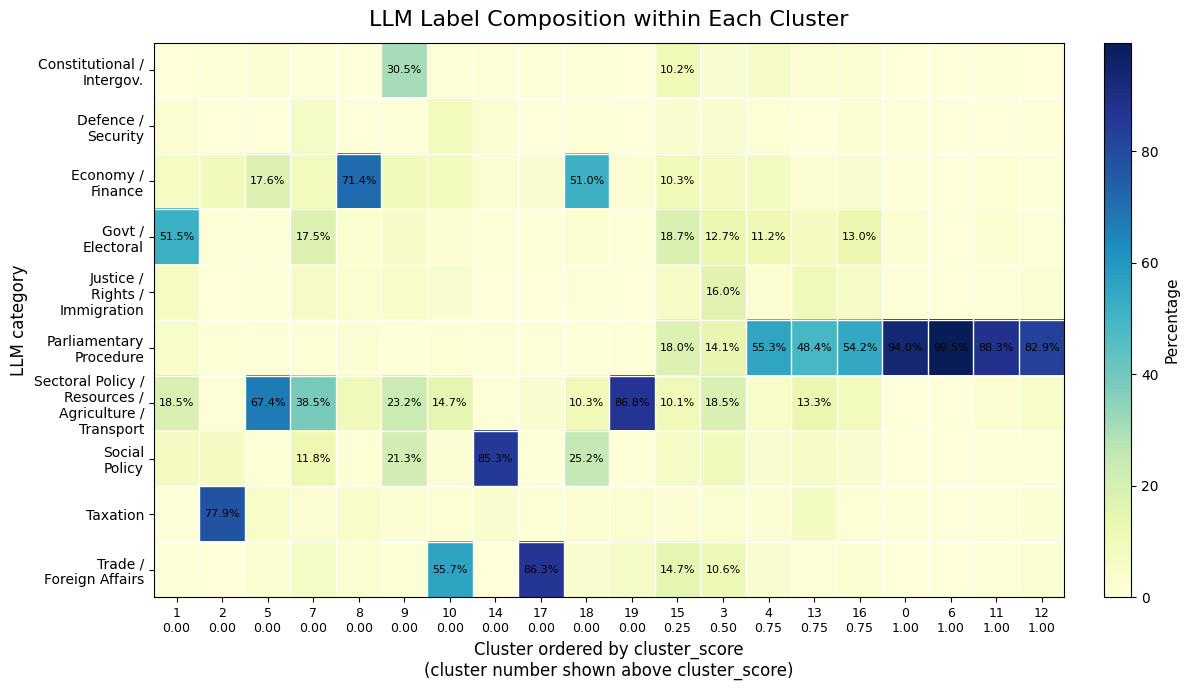

Saved figure to: e:\study\S2\Evaluating-Econometric-Methods_data\Evaluating_Econometric_Methods_MyProject\work_1953_1993\output\temp_pic\category_denominator_category_y_axis_heatmap_by_cluster_score.png


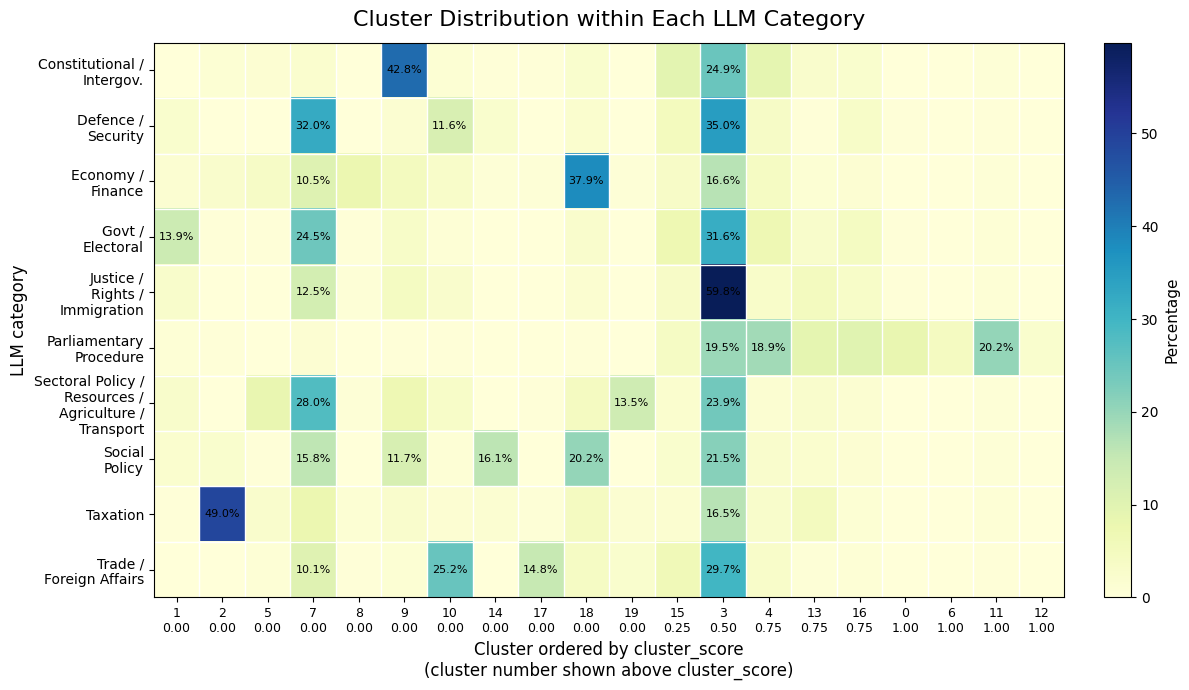

Finished.
Saved:
- cluster_denominator_category_y_axis_heatmap_by_cluster_score.png
- category_denominator_category_y_axis_heatmap_by_cluster_score.png


In [39]:
# =============================================================================
# Task cell: draw two heatmaps with categories always on the y-axis
# Cluster order is based on cluster_score, from low to high
# =============================================================================

import textwrap

CLUSTER_COLUMN = "cluster"
CATEGORY_COLUMN = "category"
CLUSTER_SCORE_COLUMN = "cluster_score"

# 只标注大于等于这个阈值的格子，避免图太乱
ANNOTATION_THRESHOLD = 10

# x轴是否显示 cluster_score
SHOW_CLUSTER_SCORE_ON_X_AXIS = True

# 如果同一个 cluster 有多个 cluster_score，默认取平均值
# 如果 cluster_score 本来就是 cluster-level 变量，那么每个 cluster 内部应该只有一个值
CLUSTER_SCORE_AGGREGATION = "mean"

CATEGORY_LABEL_MAP = {
    "Constitutional & Intergovernmental Relations": "Constitutional /\nIntergov.",
    "Defence & National Security": "Defence /\nSecurity",
    "Economy & Public Finance": "Economy /\nFinance",
    "Government & Electoral Affairs": "Govt /\nElectoral",
    "Justice, Rights & Immigration": "Justice /\nRights /\nImmigration",
    "Parliamentary Procedure": "Parliamentary\nProcedure",
    "Sectoral Policy: Resources, Agriculture & Transport": "Sectoral Policy /\nResources /\nAgriculture /\nTransport",
    "Social Policy": "Social\nPolicy",
    "Taxation": "Taxation",
    "Trade & Foreign Affairs": "Trade /\nForeign Affairs",
}


# =============================================================================
# Load only necessary columns
# =============================================================================

data = load_data(
    usecols=[
        CLUSTER_COLUMN,
        CATEGORY_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
)

check_columns_exist(
    data,
    [
        CLUSTER_COLUMN,
        CATEGORY_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
)


# =============================================================================
# Clean data
# =============================================================================

plot_data = data[
    [
        CLUSTER_COLUMN,
        CATEGORY_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
].dropna(subset=[CLUSTER_COLUMN, CATEGORY_COLUMN]).copy()

# Clean cluster
plot_data[CLUSTER_COLUMN] = pd.to_numeric(
    plot_data[CLUSTER_COLUMN],
    errors="coerce",
)

plot_data = plot_data.dropna(subset=[CLUSTER_COLUMN]).copy()
plot_data[CLUSTER_COLUMN] = plot_data[CLUSTER_COLUMN].astype(int)

# Clean category
plot_data[CATEGORY_COLUMN] = (
    plot_data[CATEGORY_COLUMN]
    .astype(str)
    .str.strip()
)

plot_data = plot_data[
    plot_data[CATEGORY_COLUMN].ne("")
].copy()

# Clean cluster_score
plot_data[CLUSTER_SCORE_COLUMN] = pd.to_numeric(
    plot_data[CLUSTER_SCORE_COLUMN],
    errors="coerce",
)

if plot_data.empty:
    raise ValueError("No valid data remained for the selected columns.")


# =============================================================================
# Helper functions
# =============================================================================

def wrap_label(label, width=22):
    """Automatically wrap long labels."""
    return "\n".join(textwrap.wrap(str(label), width=width))


def get_cluster_score_table(plot_data):
    """
    Create one cluster_score for each cluster.

    If one cluster has multiple cluster_score values, this function uses the mean.
    It also reports whether cluster_score is constant within each cluster.
    """
    score_table = (
        plot_data
        .dropna(subset=[CLUSTER_SCORE_COLUMN])
        .groupby(CLUSTER_COLUMN)[CLUSTER_SCORE_COLUMN]
        .agg(
            cluster_score="mean",
            score_min="min",
            score_max="max",
            n_unique_scores="nunique",
            n_rows="size",
        )
        .reset_index()
    )

    all_clusters = sorted(plot_data[CLUSTER_COLUMN].unique())
    clusters_with_score = set(score_table[CLUSTER_COLUMN])
    clusters_without_score = [
        cluster for cluster in all_clusters
        if cluster not in clusters_with_score
    ]

    if clusters_without_score:
        raise ValueError(
            "Some clusters do not have valid cluster_score values: "
            f"{clusters_without_score}"
        )

    non_constant_scores = score_table[
        score_table["n_unique_scores"] > 1
    ]

    if not non_constant_scores.empty:
        print(
            "Warning: Some clusters have multiple cluster_score values. "
            "The mean cluster_score is used for ordering."
        )
        display(non_constant_scores)

    score_table = score_table.sort_values(
        by=[
            "cluster_score",
            CLUSTER_COLUMN,
        ],
        ascending=[
            True,
            True,
        ],
    ).reset_index(drop=True)

    return score_table


def get_cluster_order_by_score(plot_data):
    """
    Order clusters by cluster_score from low to high.
    If cluster_score is the same, order by cluster number.
    """
    score_table = get_cluster_score_table(plot_data)

    cluster_order = score_table[CLUSTER_COLUMN].tolist()

    cluster_score_map = dict(
        zip(
            score_table[CLUSTER_COLUMN],
            score_table["cluster_score"],
        )
    )

    return cluster_order, cluster_score_map, score_table


def draw_category_y_axis_heatmap(
    plot_data,
    normalize_mode,
    title,
    output_name,
    cluster_order,
    cluster_score_map,
    annotation_threshold=10,
    category_label_map=None,
    show_cluster_score_on_x_axis=True,
):
    """
    Draw a heatmap with:
        y-axis = LLM categories
        x-axis = clusters

    The x-axis clusters are ordered by cluster_score.

    normalize_mode:
        "index"   -> denominator is each cluster.
                     Meaning: within each cluster, what percentage belongs to each category?

        "columns" -> denominator is each category.
                     Meaning: within each category, what percentage belongs to each cluster?

        None      -> raw counts.
    """

    table = pd.crosstab(
        plot_data[CLUSTER_COLUMN],
        plot_data[CATEGORY_COLUMN],
        normalize=normalize_mode,
    )

    if normalize_mode is not None:
        table = table * 100

    # Transpose so that categories are always on the y-axis
    heatmap_table = table.T

    # Keep cluster order based on cluster_score
    existing_clusters = [
        cluster for cluster in cluster_order
        if cluster in heatmap_table.columns
    ]

    heatmap_table = heatmap_table[existing_clusters]

    # Category labels
    if category_label_map is None:
        display_categories = [
            wrap_label(category, width=22)
            for category in heatmap_table.index
        ]
    else:
        display_categories = [
            category_label_map.get(
                category,
                wrap_label(category, width=22),
            )
            for category in heatmap_table.index
        ]

    # Cluster labels
    if show_cluster_score_on_x_axis:
        display_clusters = [
            f"{cluster}\n{cluster_score_map[cluster]:.2f}"
            for cluster in heatmap_table.columns
        ]
        x_axis_label = "Cluster ordered by cluster_score\n(cluster number shown above cluster_score)"
    else:
        display_clusters = [
            str(cluster)
            for cluster in heatmap_table.columns
        ]
        x_axis_label = "Cluster ordered by cluster_score"

    n_rows, n_cols = heatmap_table.shape

    figure_width = max(12, n_cols * 0.6)
    figure_height = max(7, n_rows * 0.7)

    figure, axis = plt.subplots(figsize=(figure_width, figure_height))

    image = axis.imshow(
        heatmap_table.values,
        aspect="auto",
        cmap="YlGnBu",
        interpolation="nearest",
    )

    axis.set_title(title, fontsize=16, pad=12)
    axis.set_xlabel(x_axis_label, fontsize=12)
    axis.set_ylabel("LLM category", fontsize=12)

    axis.set_xticks(range(n_cols))
    axis.set_xticklabels(
        display_clusters,
        rotation=0,
        fontsize=9,
    )

    axis.set_yticks(range(n_rows))
    axis.set_yticklabels(
        display_categories,
        fontsize=10,
    )

    # White grid lines between cells
    axis.set_xticks([x - 0.5 for x in range(1, n_cols)], minor=True)
    axis.set_yticks([y - 0.5 for y in range(1, n_rows)], minor=True)
    axis.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1,
    )
    axis.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    colorbar = figure.colorbar(
        image,
        ax=axis,
        fraction=0.03,
        pad=0.04,
    )

    if normalize_mode is None:
        colorbar.set_label("Count", fontsize=11)
    else:
        colorbar.set_label("Percentage", fontsize=11)

    # Annotate only important cells
    for row_index in range(n_rows):
        for col_index in range(n_cols):
            value = heatmap_table.iloc[row_index, col_index]

            if normalize_mode is None:
                show_text = value >= annotation_threshold
                label = f"{int(value)}"
            else:
                show_text = value >= annotation_threshold
                label = f"{value:.1f}%"

            if show_text:
                axis.text(
                    col_index,
                    row_index,
                    label,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                )

    figure.tight_layout()

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return heatmap_table


# =============================================================================
# Decide cluster order by cluster_score
# =============================================================================

cluster_order, cluster_score_map, cluster_score_table = get_cluster_order_by_score(
    plot_data
)

print("Cluster order by cluster_score:")
display(cluster_score_table)


# -----------------------------------------------------------------------------
# Heatmap 1: cluster denominator
# -----------------------------------------------------------------------------
# Meaning:
#     For each cluster, what percentage belongs to each LLM category?
# In the figure:
#     each column is one cluster;
#     each column sums to 100%.
# -----------------------------------------------------------------------------

heatmap_cluster_denominator = draw_category_y_axis_heatmap(
    plot_data=plot_data,
    normalize_mode="index",
    title="LLM Label Composition within Each Cluster",
    output_name="cluster_denominator_category_y_axis_heatmap_by_cluster_score.png",
    cluster_order=cluster_order,
    cluster_score_map=cluster_score_map,
    annotation_threshold=ANNOTATION_THRESHOLD,
    category_label_map=CATEGORY_LABEL_MAP,
    show_cluster_score_on_x_axis=SHOW_CLUSTER_SCORE_ON_X_AXIS,
)


# -----------------------------------------------------------------------------
# Heatmap 2: category denominator
# -----------------------------------------------------------------------------
# Meaning:
#     For each LLM category, what percentage is assigned to each cluster?
# In the figure:
#     each row is one category;
#     each row sums to 100%.
# -----------------------------------------------------------------------------

heatmap_category_denominator = draw_category_y_axis_heatmap(
    plot_data=plot_data,
    normalize_mode="columns",
    title="Cluster Distribution within Each LLM Category",
    output_name="category_denominator_category_y_axis_heatmap_by_cluster_score.png",
    cluster_order=cluster_order,
    cluster_score_map=cluster_score_map,
    annotation_threshold=ANNOTATION_THRESHOLD,
    category_label_map=CATEGORY_LABEL_MAP,
    show_cluster_score_on_x_axis=SHOW_CLUSTER_SCORE_ON_X_AXIS,
)


print("Finished.")
print("Saved:")
print("- cluster_denominator_category_y_axis_heatmap_by_cluster_score.png")
print("- category_denominator_category_y_axis_heatmap_by_cluster_score.png")

In [41]:
# =============================================================================
# Task cell: yearly mean of procedural_score and cluster_score
# =============================================================================

YEAR_COLUMN = "year"
PROCEDURAL_SCORE_COLUMN = "procedural_score"
CLUSTER_SCORE_COLUMN = "cluster_score"

TITLE = "Yearly Mean of Procedural Score and Cluster Score"
OUTPUT_NAME = "procedural_score_and_cluster_score_yearly_mean.png"

# If True:
#     both means are calculated from the same valid sample:
#     rows with valid year, procedural_score, and cluster_score.
#
# If False:
#     procedural_score mean uses rows with valid procedural_score;
#     cluster_score mean uses rows with valid cluster_score.
USE_SAME_VALID_SAMPLE = False

# If both scores are between 0 and 1, keeping this True makes the chart easier to compare.
SET_Y_AXIS_FROM_0_TO_1 = False


# =============================================================================
# Load only necessary columns
# =============================================================================

data = load_data(
    usecols=[
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
)

check_columns_exist(
    data,
    [
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
)


# =============================================================================
# Clean data
# =============================================================================

plot_data = data[
    [
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
].copy()

plot_data[YEAR_COLUMN] = pd.to_numeric(
    plot_data[YEAR_COLUMN],
    errors="coerce",
)

plot_data[PROCEDURAL_SCORE_COLUMN] = pd.to_numeric(
    plot_data[PROCEDURAL_SCORE_COLUMN],
    errors="coerce",
)

plot_data[CLUSTER_SCORE_COLUMN] = pd.to_numeric(
    plot_data[CLUSTER_SCORE_COLUMN],
    errors="coerce",
)

plot_data = plot_data.dropna(subset=[YEAR_COLUMN]).copy()
plot_data[YEAR_COLUMN] = plot_data[YEAR_COLUMN].astype(int)

if USE_SAME_VALID_SAMPLE:
    plot_data = plot_data.dropna(
        subset=[
            PROCEDURAL_SCORE_COLUMN,
            CLUSTER_SCORE_COLUMN,
        ]
    ).copy()


# =============================================================================
# Prepare yearly mean of procedural_score
# =============================================================================

procedural_data = plot_data.dropna(
    subset=[
        PROCEDURAL_SCORE_COLUMN,
    ]
).copy()

procedural_yearly_mean = (
    procedural_data
    .groupby(YEAR_COLUMN)[PROCEDURAL_SCORE_COLUMN]
    .mean()
    .reset_index(name="procedural_score_mean")
    .sort_values(YEAR_COLUMN)
)


# =============================================================================
# Prepare yearly mean of cluster_score
# =============================================================================

cluster_score_data = plot_data.dropna(
    subset=[
        CLUSTER_SCORE_COLUMN,
    ]
).copy()

cluster_score_yearly_mean = (
    cluster_score_data
    .groupby(YEAR_COLUMN)[CLUSTER_SCORE_COLUMN]
    .mean()
    .reset_index(name="cluster_score_mean")
    .sort_values(YEAR_COLUMN)
)


# =============================================================================
# Merge for plotting
# =============================================================================

yearly_plot_data = procedural_yearly_mean.merge(
    cluster_score_yearly_mean,
    on=YEAR_COLUMN,
    how="outer",
).sort_values(YEAR_COLUMN)


# =============================================================================
# Plot
# =============================================================================

figure, axis = plt.subplots(figsize=FIGSIZE)

axis.plot(
    yearly_plot_data[YEAR_COLUMN],
    yearly_plot_data["procedural_score_mean"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="Mean procedural_score",
)

axis.plot(
    yearly_plot_data[YEAR_COLUMN],
    yearly_plot_data["cluster_score_mean"],
    linewidth=2,
    marker="s",
    markersize=4,
    linestyle="--",
    label="Mean cluster_score",
)

axis.set_title(TITLE)
axis.set_xlabel("Year")
axis.set_ylabel("Yearly mean score")

if SET_Y_AXIS_FROM_0_TO_1:
    axis.set_ylim(0, 1)

if SHOW_GRID:
    axis.grid(True, alpha=0.3)

axis.legend(
    loc="upper left",
)

figure.tight_layout()

save_or_show_figure(
    figure=figure,
    output_name=OUTPUT_NAME,
)


# =============================================================================
# Display the underlying yearly table
# =============================================================================

yearly_plot_data

ParserError: Error tokenizing data. C error: out of memory

In [ ]:
# =============================================================================
# Task cell: stacked yearly composition plots for procedural_score and cluster_score
# Both scores are discrete values: 0, 0.25, 0.50, 0.75, 1.00
# =============================================================================

YEAR_COLUMN = "year"
PROCEDURAL_SCORE_COLUMN = "procedural_score"
CLUSTER_SCORE_COLUMN = "cluster_score"

OUTPUT_NAME_PROCEDURAL = "procedural_score_stacked_share_by_year.png"
OUTPUT_NAME_CLUSTER = "cluster_score_stacked_share_by_year.png"

# "bar"  = stacked bar chart
# "area" = stacked area chart
STACKED_PLOT_TYPE = "area"

# 固定显示顺序：从低分到高分
SCORE_ORDER = [
    "0.00",
    "0.25",
    "0.50",
    "0.75",
    "1.00",
]


# =============================================================================
# Load only necessary columns
# =============================================================================

data = load_selected_columns_streaming(
    usecols=[
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
)

check_columns_exist(
    data,
    [
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ],
)


# =============================================================================
# Clean data
# =============================================================================

plot_data = data[
    [
        YEAR_COLUMN,
        PROCEDURAL_SCORE_COLUMN,
        CLUSTER_SCORE_COLUMN,
    ]
].copy()

plot_data[YEAR_COLUMN] = pd.to_numeric(
    plot_data[YEAR_COLUMN],
    errors="coerce",
)

plot_data[PROCEDURAL_SCORE_COLUMN] = pd.to_numeric(
    plot_data[PROCEDURAL_SCORE_COLUMN],
    errors="coerce",
)

plot_data[CLUSTER_SCORE_COLUMN] = pd.to_numeric(
    plot_data[CLUSTER_SCORE_COLUMN],
    errors="coerce",
)

plot_data = plot_data.dropna(subset=[YEAR_COLUMN]).copy()
plot_data[YEAR_COLUMN] = plot_data[YEAR_COLUMN].astype(int)


# =============================================================================
# Helper functions
# =============================================================================

def prepare_yearly_stacked_share_from_exact_values(
    data,
    score_column,
    score_order=SCORE_ORDER,
    year_column=YEAR_COLUMN,
):
    """
    Calculate yearly shares using exact values of a discrete score variable.

    Example score values:
        0, 0.25, 0.50, 0.75, 1.00
    """
    temp = data[
        [
            year_column,
            score_column,
        ]
    ].dropna().copy()

    temp[score_column] = pd.to_numeric(
        temp[score_column],
        errors="coerce",
    )

    temp = temp.dropna(subset=[score_column]).copy()

    # 防止 0.2500000001 这类浮点误差
    temp[score_column] = temp[score_column].round(2)

    temp["score_group"] = temp[score_column].map(
        lambda x: f"{x:.2f}"
    )

    yearly_counts = (
        temp
        .groupby([year_column, "score_group"])
        .size()
        .rename("count")
        .reset_index()
    )

    yearly_totals = (
        temp
        .groupby(year_column)
        .size()
        .rename("year_total")
        .reset_index()
    )

    yearly_shares = yearly_counts.merge(
        yearly_totals,
        on=year_column,
        how="left",
        validate="many_to_one",
    )

    yearly_shares["share"] = (
        yearly_shares["count"]
        / yearly_shares["year_total"]
    )

    share_table = yearly_shares.pivot(
        index=year_column,
        columns="score_group",
        values="share",
    ).fillna(0)

    # 保证每张图的颜色和顺序一致
    existing_order = [
        score for score in score_order
        if score in share_table.columns
    ]

    missing_order = [
        score for score in score_order
        if score not in share_table.columns
    ]

    for score in missing_order:
        share_table[score] = 0

    share_table = share_table[score_order]
    share_table = share_table.sort_index()

    return share_table


def plot_stacked_share(
    share_table,
    title,
    output_name,
    plot_type="bar",
):
    """
    Draw stacked bar chart or stacked area chart from a yearly share table.
    """
    figure, axis = plt.subplots(figsize=FIGSIZE)

    if plot_type == "bar":
        share_table.plot(
            kind="bar",
            stacked=True,
            ax=axis,
            width=0.85,
        )

        axis.set_xlabel("Year")

    elif plot_type == "area":
        axis.stackplot(
            share_table.index,
            [
                share_table[column]
                for column in share_table.columns
            ],
            labels=share_table.columns,
        )

        axis.set_xlabel("Year")

    else:
        raise ValueError("plot_type must be either 'bar' or 'area'.")

    axis.set_title(title)
    axis.set_ylabel("Share")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    axis.set_ylim(0, 1)

    if SHOW_GRID:
        axis.grid(True, axis="y", alpha=0.3)

    axis.legend(
        title="Score",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    figure.tight_layout()

    save_or_show_figure(
        figure=figure,
        output_name=output_name,
    )

    return figure, axis


# =============================================================================
# Plot 1: procedural_score stacked composition
# =============================================================================

procedural_share_table = prepare_yearly_stacked_share_from_exact_values(
    data=plot_data,
    score_column=PROCEDURAL_SCORE_COLUMN,
)

plot_stacked_share(
    share_table=procedural_share_table,
    title="Yearly Composition of Procedural Score",
    output_name=OUTPUT_NAME_PROCEDURAL,
    plot_type=STACKED_PLOT_TYPE,
)


# =============================================================================
# Plot 2: cluster_score stacked composition
# =============================================================================

cluster_score_share_table = prepare_yearly_stacked_share_from_exact_values(
    data=plot_data,
    score_column=CLUSTER_SCORE_COLUMN,
)

plot_stacked_share(
    share_table=cluster_score_share_table,
    title="Yearly Composition of Cluster Score",
    output_name=OUTPUT_NAME_CLUSTER,
    plot_type=STACKED_PLOT_TYPE,
)


print("Finished.")
print("Saved:")
print(f"- {OUTPUT_NAME_PROCEDURAL}")
print(f"- {OUTPUT_NAME_CLUSTER}")